In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

In [4]:
from sklearn.datasets import fetch_california_housing
data = fetch_california_housing()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['Price'] = data.target
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [6]:
print(df.shape)
print(df.describe())
print(df.isnull().sum())

(20640, 9)
             MedInc      HouseAge      AveRooms     AveBedrms    Population  \
count  20640.000000  20640.000000  20640.000000  20640.000000  20640.000000   
mean       3.870671     28.639486      5.429000      1.096675   1425.476744   
std        1.899822     12.585558      2.474173      0.473911   1132.462122   
min        0.499900      1.000000      0.846154      0.333333      3.000000   
25%        2.563400     18.000000      4.440716      1.006079    787.000000   
50%        3.534800     29.000000      5.229129      1.048780   1166.000000   
75%        4.743250     37.000000      6.052381      1.099526   1725.000000   
max       15.000100     52.000000    141.909091     34.066667  35682.000000   

           AveOccup      Latitude     Longitude         Price  
count  20640.000000  20640.000000  20640.000000  20640.000000  
mean       3.070655     35.631861   -119.569704      2.068558  
std       10.386050      2.135952      2.003532      1.153956  
min        0.692308  

In [7]:
X = df.drop('Price', axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (16512, 8)
Testing size: (4128, 8)


In [8]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
print("Model trained successfully!")

Model trained successfully!


In [9]:
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)
print("Accuracy:", round(r2 * 100, 2), "%")

Mean Squared Error: 0.2553684927247781
R2 Score: 0.8051230593157366
Accuracy: 80.51 %


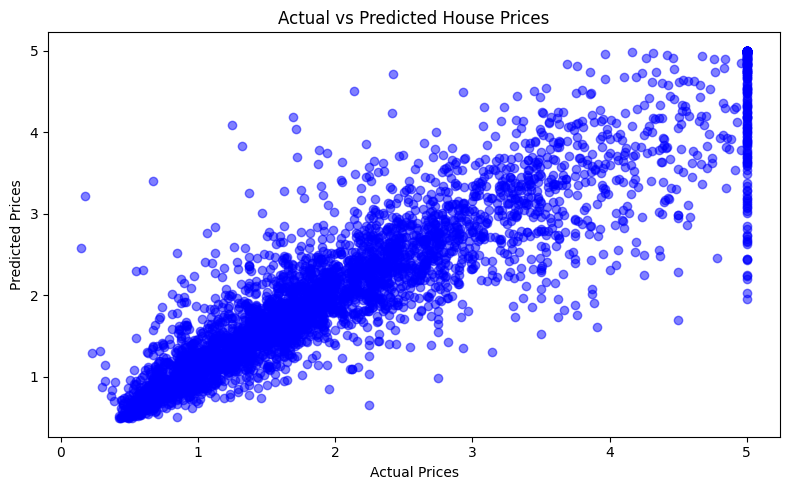

In [10]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha=0.5, color='blue')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.tight_layout()
plt.show()

In [11]:
my_house = np.array([[5.0, 20.0, 6.0, 1.0, 800.0, 3.0, 34.0, -118.0]])
predicted_price = model.predict(my_house)
print("Predicted Price:", round(predicted_price[0], 2), "($100,000s)")

Predicted Price: 2.38 ($100,000s)


Saved!


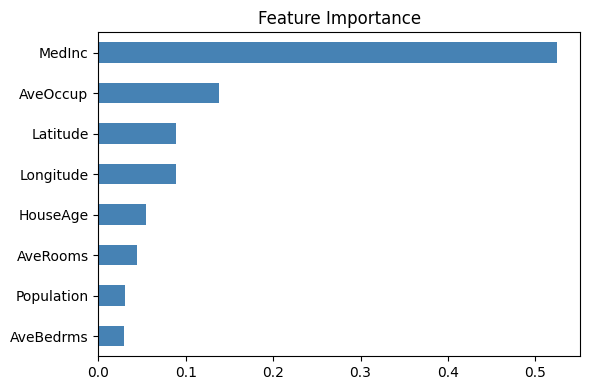

In [12]:
import pandas as pd
feat_importance = pd.Series(model.feature_importances_,
                index=data.feature_names)
feat_importance.sort_values().plot(kind='barh',
                                    color='steelblue',
                                    figsize=(6,4))
plt.title("Feature Importance")
plt.tight_layout()
plt.savefig('feature_importance.png')
print("Saved!")

In [14]:
import plotly.express as px
residuals = y_pred - y_test

fig = px.scatter(
    x=y_test,
    y=residuals,
    labels={"x": "Actual Prices", "y": "Residuals"},
    opacity=0.6
)

fig.add_hline(y=0, line_dash="dash", line_color="red")

fig.update_layout(
    title="Residuals vs Actual Prices",
    xaxis_title="Actual Prices",
    yaxis_title="Residuals"
)

fig.show()

In [15]:
import plotly.express as px

residuals = y_pred - y_test

fig = px.histogram(
    x=residuals,
    nbins=30,
    labels={"x": "Residuals", "y": "Count"}
)

fig.update_layout(
    title="Distribution of Prediction Errors",
    xaxis_title="Residuals",
    yaxis_title="Count"
)

fig.show()

In [16]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=list(range(len(y_test))),
    y=y_test,
    mode="lines",
    name="Actual"
))

fig.add_trace(go.Scatter(
    x=list(range(len(y_pred))),
    y=y_pred,
    mode="lines",
    name="Predicted"
))

fig.update_layout(
    title="Actual vs Predicted Over Samples",
    xaxis_title="Sample Index",
    yaxis_title="Price"
)

fig.show()

In [17]:
import plotly.graph_objects as go

predicted_price = model.predict(my_house)[0]

fig = go.Figure([
    go.Bar(x=["Predicted Price"], y=[predicted_price], name="Prediction")
])

fig.update_layout(
    title="Predicted Price for One House",
    yaxis_title="Price ($100,000s)",
    xaxis_title="House"
)

fig.show()